In [1]:
from pathlib import Path
from os import environ


# IN_COLAB = False
# if "DRIVE_HOME" in environ:
  # ROOT = Path(f"{environ.get("DRIVE_HOME")}/colab/outputs/waterloo-slt-reading-group")
# else:
ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixture/poisson2d")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/rlct")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/rlct


In [2]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [3]:
from sklearn_extensions.mixpoisson import PoissonMixture
from scipy_extensions import mixpoisson


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
  return truth

def rlct_by_dsid(dsid: str):
  truth = find_truth_by_dsid(dsid)
  n_components = np.ceil(len(truth)/2)
  rlct = None
  match dsid:
    case "regular" | "e-singular":
      rlct = (n_components*2-1)/2
    case "singular1" | "singular2":
      rlct = 1
    case _:
      raise Exception(f"Uknown dsid={dsid}")

  return rlct

def approx_free_energy_by_dsid(dsid, X):
  n=len(X)
  
  average_log_likelihood = None
  model = PoissonMixture(n_components=3, enforce_ordering=False)
  input_data = np.column_stack([X])
  model.fit(input_data)
  mle, _ = model.point_estimate()
  log_p = mixpoisson.logpmf(weights=[mle[2], 1-mle[2]], mus=[mle[0], mle[1]], x=X) # sample likelihood under the mle
  average_log_likelihood = log_p.mean()

  afe = -n_obs*average_log_likelihood+rlct_by_dsid(dsid)*np.log(n_obs)
  return afe


def expected_free_energy_by_dsid(dsid, n, x_max=100):
  X = np.arange(0, x_max, 1)
  truth = find_truth_by_dsid(dsid)
  weights_0=truth[2:3]
  mus_0=truth[0:1]

  log_q = mixpoisson.logpmf(weights=weights_0, mus=mus_0, x=X)
  log_p = mixpoisson.logpmf(weights=weights_0, mus=mus_0, x=X)
  expected_log_likelihood = np.exp(log_q)*log_p
  second_order_term = rlct_by_dsid(dsid)*np.log(n)

  efe = -n * expected_log_likelihood.sum() + second_order_term
  return efe

In [4]:
import pandas as pd
import json
from pathlib import Path

results_file = Path(f"{outputdir}/estimators_data.csv")

# Load existing results if file exists
if results_file.exists():
  estimators_df = pd.read_csv(results_file)
  # Create a set of completed (run, regime, dsid) tuples for fast lookup
  completed = set(
      zip(estimators_df["trial"], estimators_df["regime"], estimators_df["dsid"], estimators_df["hypers"])
  )
  estimators_data = estimators_df.to_dict("records")
else:
  completed = set()
  estimators_data = []

def save_results():
  """Save current results to disk."""
  pd.DataFrame(estimators_data).to_csv(results_file, index=False)

In [48]:
from pymc_extensions.tempered_mixpoisson import TemperedPoissonMixture
from pymc_extensions import pmx
from scipy_extensions import mixpoisson
from tqdm.notebook import tqdm
import pymc as pm
import numpy as np
import arviz as az
import time


n_components = 2
regimes = [50, 250, 5000]

# mcmc settings
n_tune=4000
n_draws=1000
n_chains=4
c_values=[1, 1]
d_values=[1/10, 1]

# read all the data so we can nicely loop 
for run in tqdm(range(1000), desc=f"runs "):
  # if run > 10:
  #   break
  for c_index, c in enumerate(c_values):
    d = d_values[c_index]
    hypers = f"c={c},d={d}"
    for regime in tqdm(regimes, desc="regimes"):
      for dsid in dgps["dsid"].unique():
        dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")
  
        X = dataset.iloc[:, run].to_numpy()
        n_obs = len(X)

        # Skip if already completed
        if (run, regime, dsid, hypers) in completed:
          print(f"skipped run={run}, dsid={dsid}, regime={regime}, hypers={hypers}")
          continue
        start = time.perf_counter()
  
        beta = c/np.log(n_obs)
        delta = d/np.log(n_obs)

        ll0 = None
        with TemperedPoissonMixture(X=X, beta=beta) as model:
          idata = model.sample(draws=n_draws, 
                               tune=n_tune, 
                               chains=n_chains, 
                               progressbar=False)  # or "blackjax"

          weights = pmx.column_stack_vars(idata, ["weights"])
          mus = pmx.column_stack_vars(idata, ["mus"])
          log_likelihood = mixpoisson.log_likelihood(weights, mus, x=X)
          ll0 = log_likelihood.mean()
  
        # Divergences are stored in sample_stats as a boolean array (chain, draw)
        diverging = idata.sample_stats.diverging.values
        
        # Divergences per chain
        divs_per_chain0 = diverging.sum(axis=1)  # array with one value per chain
        
        # Summary statistics
        mean_divergences0 = divs_per_chain0.mean()
        total_divergences0 = diverging.sum()
        max_divergences0 = divs_per_chain0.max()
        tree_depth0=idata.sample_stats.tree_depth.values.max()

        ll1=None
        with TemperedPoissonMixture(X=X, beta=beta+delta) as model:
          idata = model.sample(draws=n_draws, 
                               tune=n_tune, 
                               chains=n_chains, 
                               progressbar=False)  # or "blackjax"

          weights = pmx.column_stack_vars(idata, ["weights"])
          mus = pmx.column_stack_vars(idata, ["mus"])
          log_likelihood = mixpoisson.log_likelihood(weights, mus, x=X)
          ll1 = log_likelihood.mean()

        # Divergences are stored in sample_stats as a boolean array (chain, draw)
        diverging = idata.sample_stats.diverging.values
        
        # Divergences per chain
        divs_per_chain1 = diverging.sum(axis=1)  # array with one value per chain
        
        # Summary statistics
        mean_divergences1 = divs_per_chain1.mean()
        total_divergences1 = diverging.sum()
        max_divergences1 = divs_per_chain1.max()
        tree_depth1=idata.sample_stats.tree_depth.values.max()
        
        rlct=(ll0-ll1)/(1/(beta+delta)-1/beta)

        end = time.perf_counter()
        print(f"run={run}, regime={regime}, c={c},d={d}, dsid={dsid}, rlct_watanabe={rlct}, duration={end-start:.6f}")
        
        result = {
          "dsid": dsid,
          "regime": regime,
          "n": regime,
          "trial": run,
          "rlct": rlct,
          "hypers": hypers,
          "name": "watanabe",
          "chains": n_chains,
          "draws": n_draws,
          "tune": n_tune,
          "mean_divergences": (mean_divergences0+mean_divergences1)/2,
          "total_divergences": np.sum(total_divergences0, total_divergences1),
          "max_divergences": np.max(max_divergences0, max_divergences1),
          "divergences_per_chain": divs_per_chain0.tolist()+divs_per_chain1.tolist(),
          "chain_tree_depth": np.max([tree_depth0, tree_depth1]),
          "duration": end-start
        }
  
        estimators_data.append(result)
        completed.add((run, regime, dsid, hypers))
  
      # Save after each successful run
      save_results()
      !git add "../../outputs/mixture/poisson2d/rlct/estimators_data.csv"
      !git commit -m "more runs"
      !git push

runs :   0%|          | 0/1000 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

skipped run=0, dsid=regular, regime=50, hypers=c=1,d=0.1
skipped run=0, dsid=e-singular, regime=50, hypers=c=1,d=0.1
skipped run=0, dsid=singular1, regime=50, hypers=c=1,d=0.1
skipped run=0, dsid=singular2, regime=50, hypers=c=1,d=0.1
skipped run=0, dsid=regular, regime=250, hypers=c=1,d=0.1
skipped run=0, dsid=e-singular, regime=250, hypers=c=1,d=0.1
skipped run=0, dsid=singular1, regime=250, hypers=c=1,d=0.1
skipped run=0, dsid=singular2, regime=250, hypers=c=1,d=0.1
skipped run=0, dsid=regular, regime=5000, hypers=c=1,d=0.1
skipped run=0, dsid=e-singular, regime=5000, hypers=c=1,d=0.1
skipped run=0, dsid=singular1, regime=5000, hypers=c=1,d=0.1
skipped run=0, dsid=singular2, regime=5000, hypers=c=1,d=0.1


regimes:   0%|          | 0/3 [00:00<?, ?it/s]

skipped run=0, dsid=regular, regime=50, hypers=c=1,d=1
skipped run=0, dsid=e-singular, regime=50, hypers=c=1,d=1
skipped run=0, dsid=singular1, regime=50, hypers=c=1,d=1
skipped run=0, dsid=singular2, regime=50, hypers=c=1,d=1
skipped run=0, dsid=regular, regime=250, hypers=c=1,d=1
skipped run=0, dsid=e-singular, regime=250, hypers=c=1,d=1
skipped run=0, dsid=singular1, regime=250, hypers=c=1,d=1
skipped run=0, dsid=singular2, regime=250, hypers=c=1,d=1
skipped run=0, dsid=regular, regime=5000, hypers=c=1,d=1
skipped run=0, dsid=e-singular, regime=5000, hypers=c=1,d=1
skipped run=0, dsid=singular1, regime=5000, hypers=c=1,d=1
skipped run=0, dsid=singular2, regime=5000, hypers=c=1,d=1


...

run=10, regime=5000, c=1,d=1, dsid=e-singular, rlct_watanabe=1.455812198185738, duration=56.604260


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


run=10, regime=5000, c=1,d=1, dsid=singular1, rlct_watanabe=0.8504227741452365, duration=212.419977


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


run=10, regime=5000, c=1,d=1, dsid=singular2, rlct_watanabe=0.7431293284034034, duration=196.811913


In [49]:
rlct_estimates_df = pd.DataFrame(estimators_data)
rlct_estimates_df

,dsid,regime,n,trial,rlct,hypers,name,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,duration
0,singular2,5000,5000,0,0.959683,"c=1,d=0.1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN
1,singular2,5000,5000,0,0.839289,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN
2,singular2,5000,5000,1,0.816095,"c=1,d=0.1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN
3,singular2,5000,5000,1,0.905477,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN
4,singular2,5000,5000,2,1.453012,"c=1,d=0.1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,singular2,250,250,10,0.846107,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,11.684365
265,regular,5000,5000,10,1.399207,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",5,34.246411
266,e-singular,5000,5000,10,1.455812,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",7,56.604260
267,singular1,5000,5000,10,0.850423,"c=1,d=1",watanabe,4,1000,4000,0.0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0]",10,212.419977


In [50]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# dsids = rlct_estimates_df['dsid'].unique()
# n_values = sorted(rlct_estimates_df['n'].unique())

# g = sns.FacetGrid(
#     rlct_estimates_df, 
#     row='dsid', 
#     col='n', 
#     height=4, 
#     aspect=1.2,
#     sharey='row',
#     row_order=dsids[::-1],
#     col_order=n_values
# )

# g.map_dataframe(
#     sns.boxplot, 
#     x='hypers', 
#     y='rlct', 
#     hue='hypers',
#     palette='Set2',
#     legend=False,
#     fliersize=2
# )

# # Add true RLCT lines to each row
# for i, dsid in enumerate(dsids[::-1]):
#     true_rlct = rlct_by_dsid(dsid)
#     for j, n in enumerate(n_values):
#         ax = g.axes[i, j]
#         ax.axhline(true_rlct, color='red', linestyle='--', linewidth=2)

# g.set_axis_labels('', 'RLCT estimate')
# g.set_titles(row_template='{row_name}', col_template='n = {col_name}')

# for ax in g.axes.flat:
#     ax.tick_params(axis='x', rotation=45)

# plt.suptitle('RLCT Estimation by Hyperparameters', y=1.02)
# plt.tight_layout()
# plt.show()

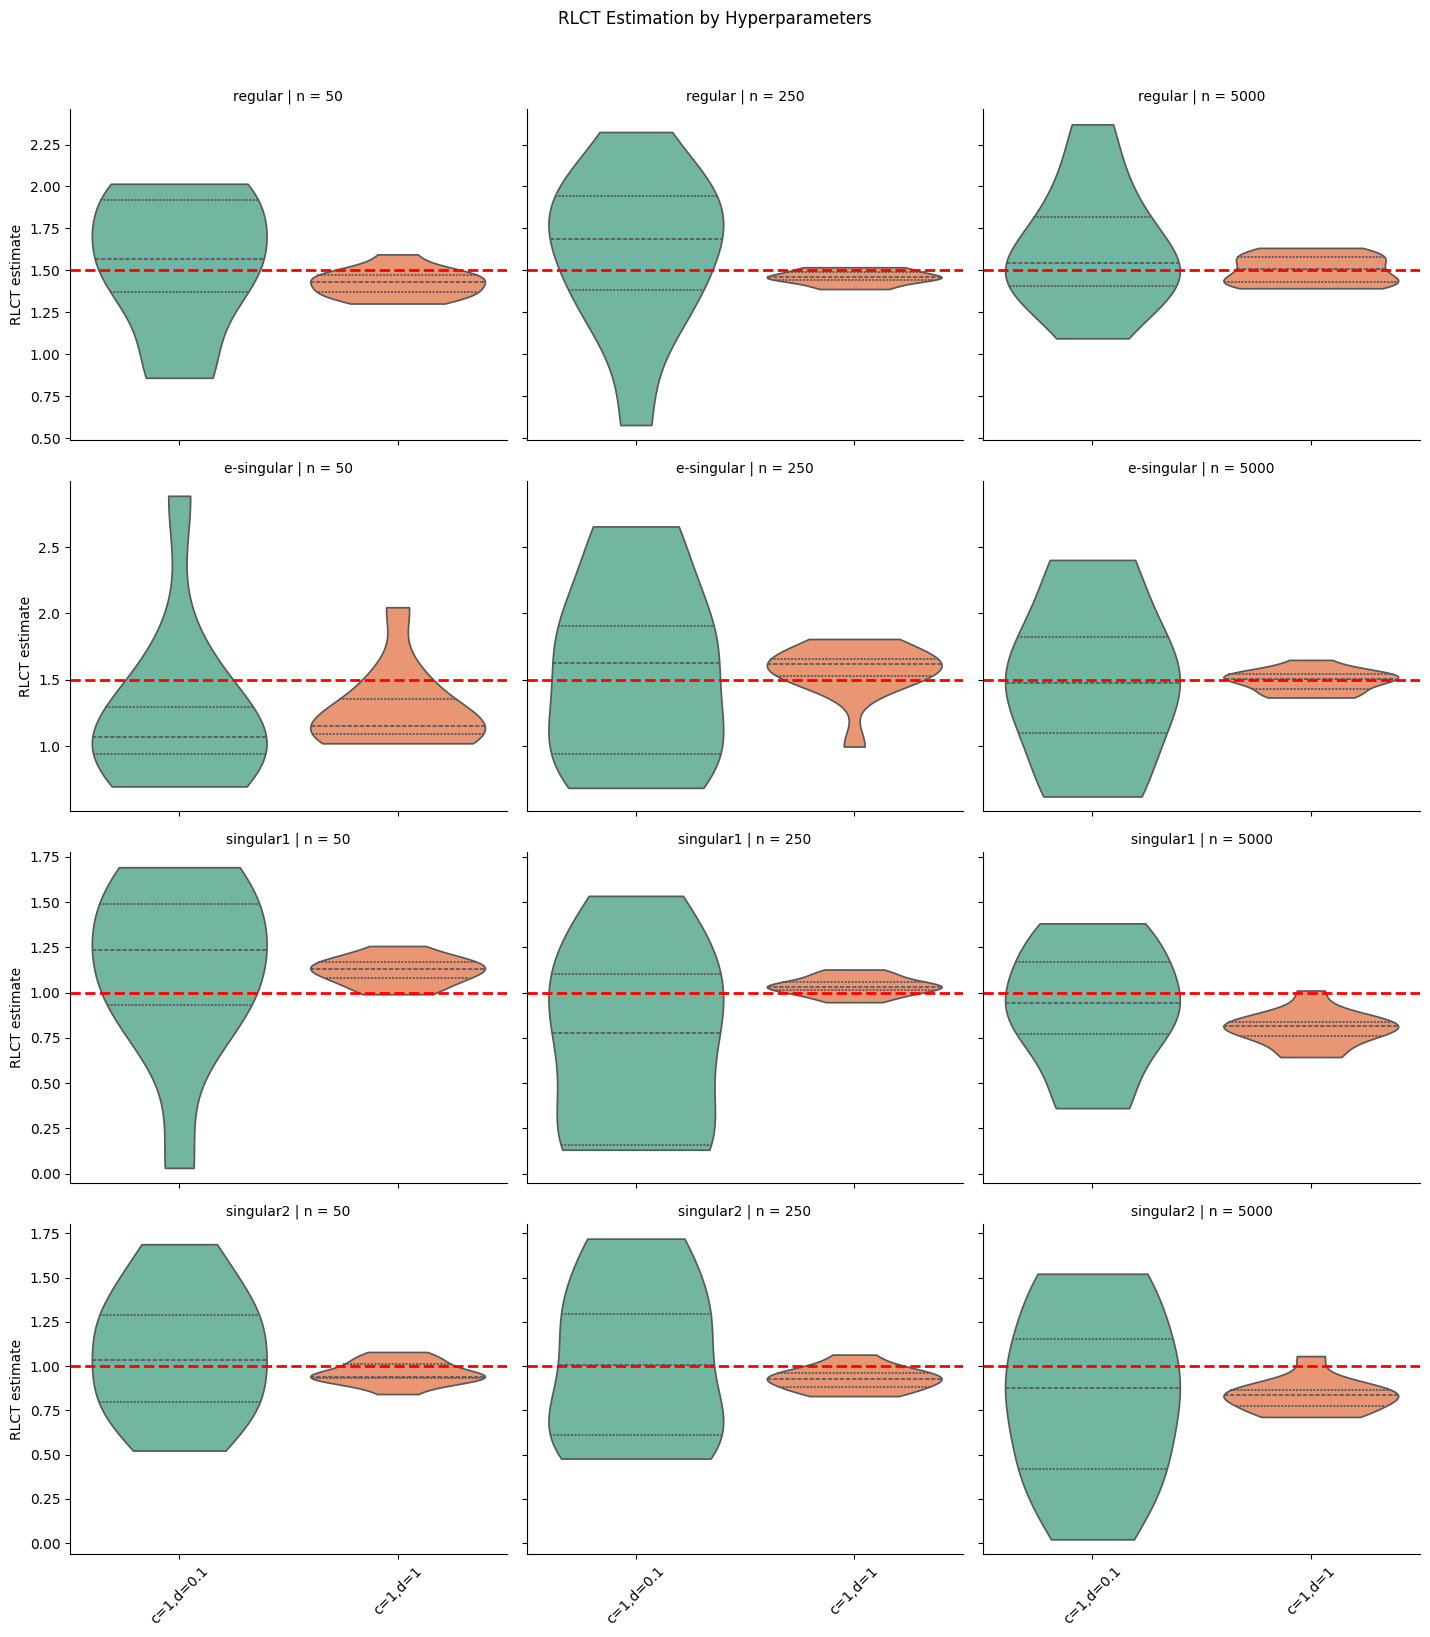

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dsids = rlct_estimates_df['dsid'].unique()
n_values = sorted(rlct_estimates_df['n'].unique())

g = sns.FacetGrid(
    rlct_estimates_df, 
    row='dsid', 
    col='n', 
    height=4, 
    aspect=1.2,
    sharey='row',
    row_order=dsids[::-1],
    col_order=n_values
)

g.map_dataframe(
    sns.violinplot, 
    x='hypers', 
    y='rlct', 
    hue='hypers',
    palette='Set2',
    legend=False,
    cut=0,  # Don't extend beyond data range
    inner='quart'  # Show quartiles inside violin
)

# Add true RLCT lines to each row
for i, dsid in enumerate(dsids[::-1]):
    true_rlct = rlct_by_dsid(dsid)
    for j, n in enumerate(n_values):
        ax = g.axes[i, j]
        ax.axhline(true_rlct, color='red', linestyle='--', linewidth=2)

g.set_axis_labels('', 'RLCT estimate')
g.set_titles(row_template='{row_name}', col_template='n = {col_name}')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('RLCT Estimation by Hyperparameters', y=1.02)
plt.tight_layout()
plt.show()

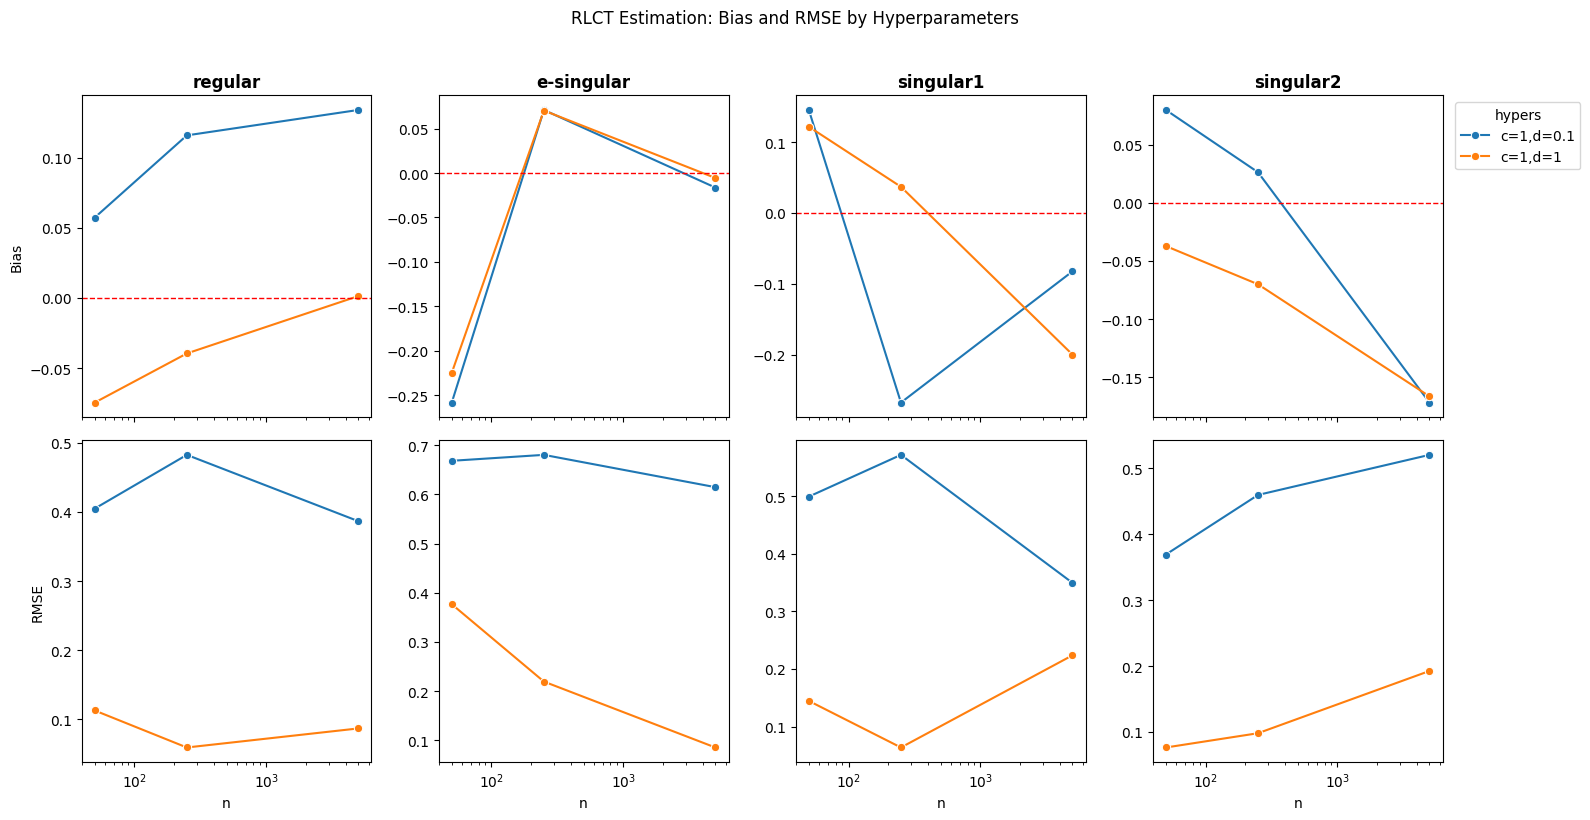

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = rlct_estimates_df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std'),
    median_rlct=('rlct', 'median')
).reset_index()

# Add true RLCT and compute bias/rmse
summary['true_rlct'] = summary['dsid'].apply(rlct_by_dsid)
summary['bias'] = summary['mean_rlct'] - summary['true_rlct']
summary['rmse'] = np.sqrt(summary['bias']**2 + summary['std_rlct']**2)

dsids = ['regular', 'e-singular', 'singular1', 'singular2']

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True)

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Bias
    ax = axes[0, j]
    sns.lineplot(
        data=data,
        x='n',
        y='bias',
        hue='hypers',
        marker='o',
        ax=ax
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_title(dsid, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Bias' if j == 0 else '')
    
    if j < len(dsids) - 1:
        ax.get_legend().remove()
    else:
        ax.legend(title='hypers', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: RMSE
    ax = axes[1, j]
    sns.lineplot(
        data=data,
        x='n',
        y='rmse',
        hue='hypers',
        marker='o',
        ax=ax
    )
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('RMSE' if j == 0 else '')
    ax.get_legend().remove()

plt.suptitle('RLCT Estimation: Bias and RMSE by Hyperparameters', y=1.02)
plt.tight_layout()
plt.show()

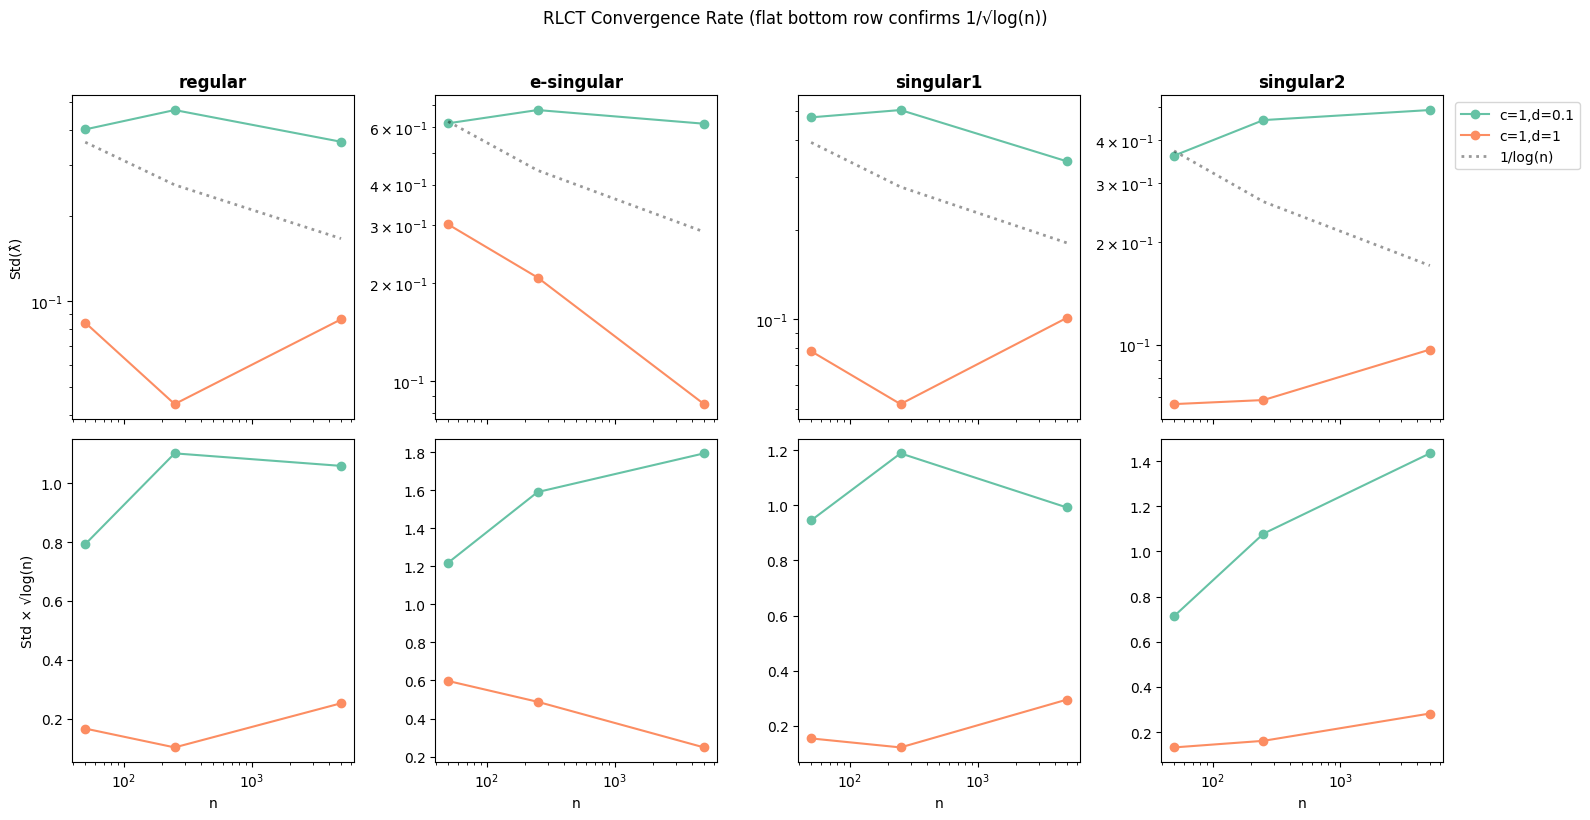

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = rlct_estimates_df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std')
).reset_index()

summary['true_rlct'] = summary['dsid'].apply(rlct_by_dsid)
summary['std_normalized'] = summary['std_rlct'] * np.sqrt(np.log(summary['n']))

dsids = ['regular', 'e-singular', 'singular1', 'singular2']
hypers_list = summary['hypers'].unique()
palette = sns.color_palette('Set2', len(hypers_list))
hyper_colors = dict(zip(hypers_list, palette))

n_range = np.array(sorted(summary['n'].unique()))

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True)

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Std with reference line
    ax = axes[0, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_rlct'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    # Reference line anchored at midpoint
    mid_idx = len(n_range) // 2
    ref_n = n_range[mid_idx]
    ref_std = data.groupby('n')['std_rlct'].mean().iloc[mid_idx]
    
    ax.plot(n_range, ref_std * (np.log(ref_n) / np.log(n_range)), 
            'k:', alpha=0.4, linewidth=2, label='1/log(n)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('Std(λ̂)' if j == 0 else '')
    ax.set_title(dsid, fontweight='bold')
    
    if j == len(dsids) - 1:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: Std × √log(n)
    ax = axes[1, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_normalized'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('Std × √log(n)' if j == 0 else '')
    ax.get_legend().remove() if ax.get_legend() else None

plt.suptitle('RLCT Convergence Rate (flat bottom row confirms 1/√log(n))', y=1.02)
plt.tight_layout()
plt.show()